<table><tr><th><div style='padding:15px;color:#030aa7;font-size:240%;text-align:center;font-style:italic;font-weight:bold;font-family:Georgia,serif'>Situer et relier — Logs web</div></th></tr></table>

<div style='text-align:center'><img src='https://raw.githubusercontent.com/rbizoi/dockerBigDataBI/refs/heads/master/images/bi/famille_7.png' width='1024'></div>
<div style='text-align:center'><img src='https://raw.githubusercontent.com/rbizoi/dockerBigDataBI/refs/heads/master/images/bi/famille_7_description.png' width='1024'></div>

<div style='padding:15px;color:#030aa7;font-family:Georgia,serif'>Atelier BI · Famille 07 · 6 graphiques × 3 bibliothèques</div>

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Introduction</div></b>

Le fichier couvre seulement le 22 janvier 2019, de 00:26 à 07:36 UTC environ. Les premières et dernières minutes sont incomplètes. Les mesures portent sur des requêtes, pas sur des personnes. Les adresses IP et URL brutes ne sont pas chargées.

**Objectif :** construire les six représentations de cette famille sur les données réelles, comparer les encodages et interpréter leurs limites. Les trois variantes utilisent exactement la même table préparée. Les constructions composites Seaborn sont signalées : cette bibliothèque ne propose pas tous les types nativement.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Sommaire</div></b>

1. Carte choroplèthe
2. Carte à symboles
3. Matrice thermique ou heatmap
4. Sankey
5. Réseau de relations
6. Gantt ou chronologie de tâches

Exécution : ouvrir le dossier extrait, sélectionner un noyau Python avec les dépendances de `requirements.txt`, puis **Redémarrer le noyau et tout exécuter**. Les résultats sont déjà enregistrés. Adapter `config_donnees.json` si les fichiers changent de place.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Import des bibliothèques</div></b>

In [1]:
NOM_PROJET = '07_web'
from pathlib import Path
import os, json, warnings
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle, Polygon, Wedge
from matplotlib.collections import PatchCollection
from matplotlib.colors import Normalize
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
from scipy.stats import gaussian_kde
import networkx as nx
import squarify

get_ipython().run_line_magic('matplotlib', 'inline')
SEED = 42
palette = ["#030aa7", "#e50000", "#d8863b", "#005f6a", "#6b7c85", "#751973",
           "#0485d1", "#ff7855", "#fbeeac", "#0cb577", "#95a3a6", "#c071fe"]
sns.set_theme(style='darkgrid', palette=palette, context='notebook', font_scale=1.05)
plt.rcParams.update({'figure.figsize': (11, 5), 'figure.dpi': 110})
pio.templates['bi_modele'] = pio.templates['plotly_white']
pio.templates['bi_modele'].layout.colorway = palette
pio.templates.default = 'bi_modele'
pio.renderers.default = 'plotly_mimetype'
px.defaults.color_discrete_sequence = palette
EXPORTER = False  # True : PNG statiques et HTML interactifs dans repertoire.images.
repertoireImages = Path('repertoire.images') / NOM_PROJET

def sauvegarderImage(nom, fig=None):
    fig = fig if fig is not None else plt.gcf()
    if EXPORTER:
        repertoireImages.mkdir(parents=True, exist_ok=True)
        fig.savefig(repertoireImages / (nom + '.png'), dpi=180, bbox_inches='tight')

def terminer(ax, titre, xlabel=None, ylabel=None):
    ax.set_title(titre, loc='left', fontweight='bold', pad=14)
    if xlabel is not None: ax.set_xlabel(xlabel)
    if ylabel is not None: ax.set_ylabel(ylabel)
    ax.figure.tight_layout()
    sauvegarderImage(ID_GRAPHIQUE + '_' + BIBLIOTHEQUE, ax.figure)
    plt.show()
    plt.close(ax.figure)

def montrer_plotly(fig, titre):
    fig.update_layout(title=titre, width=1000, height=520,
                      margin=dict(l=70, r=45, t=90, b=75),
                      font=dict(family='Arial', size=13))
    if EXPORTER:
        repertoireImages.mkdir(parents=True, exist_ok=True)
        fig.write_html(repertoireImages / (ID_GRAPHIQUE + '_plotly.html'), include_plotlyjs=True)
    fig.show()

def creer_axes(seaborn=False, **kwargs):
    # Matplotlib reste autonome ; Seaborn garde le style et la palette du modèle.
    plt.style.use('default')
    if seaborn: sns.set_theme(style='darkgrid', palette=palette, context='notebook')
    return plt.subplots(figsize=(11, 5), **kwargs)

print('Versions :', 'pandas', pd.__version__, 'seaborn', sns.__version__,
      'plotly', __import__('plotly').__version__, 'matplotlib', __import__('matplotlib').__version__)

Versions : pandas 2.3.3 seaborn 0.13.2 plotly 7.1.0 matplotlib 3.10.9


## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Outils du document</div></b>

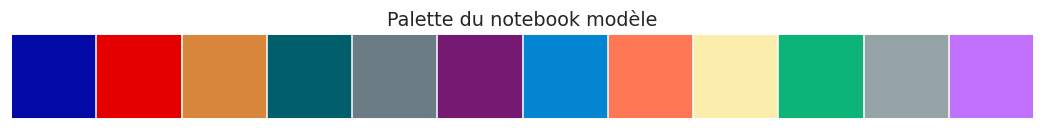

In [2]:
sns.palplot(sns.color_palette(palette))
plt.title('Palette du notebook modèle')
plt.show()
plt.close('all')

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Lecture des données</div></b>

<table><tr><th style="background:#053061;color:white">Colonne</th><th style="background:#053061;color:white">Description</th></tr><tr><td>datetime</td><td>Horodatage UTC</td></tr><tr><td>status / classe_http</td><td>Code HTTP et famille de code</td></tr><tr><td>bytes / taille_ko</td><td>Octets transférés et kilo-octets binaires (÷ 1024)</td></tr><tr><td>device_type / referer_type</td><td>Classe appareil et type de référent déjà présents dans le fichier</td></tr><tr><td>is_bot</td><td>Détection de robot fournie, non réestimée</td></tr><tr><td>geo_country_code / geo_latitude / geo_longitude</td><td>Géolocalisation fournie, indicative ; pas une position individuelle vérifiée</td></tr></table>

In [3]:
CHEMINS = {'meteo': '/opt/spark/data/meteo.gzip', 'web': '/opt/spark/data/Web.Server.Access10.gzip', 'ecommerce': '/opt/spark/notebooks/ecommerce'}
configuration = Path('config_donnees.json')
if configuration.exists():
    CHEMINS.update(json.loads(configuration.read_text(encoding='utf-8')))
for cle in CHEMINS:
    CHEMINS[cle] = os.environ.get('BI_' + cle.upper(), CHEMINS[cle])
assert Path(CHEMINS['web']).exists(), 'Vérifier config_donnees.json'

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Contrôle des données et préparation</div></b>

In [4]:
colonnes = ['datetime', 'method', 'status', 'bytes', 'device_type', 'referer_type',
            'is_bot', 'geo_country_code', 'geo_latitude', 'geo_longitude', 'url_parameter_count']
brut = pd.read_parquet(CHEMINS['web'], columns=colonnes)
donnees = brut.copy()
donnees['datetime'] = pd.to_datetime(donnees['datetime'], utc=True, errors='coerce')
valides = donnees['datetime'].notna() & donnees['status'].between(100, 599) & donnees['bytes'].ge(0)
print(f'Lignes source : {len(brut):,} ; hors critères techniques : {(~valides).sum():,}')
donnees = donnees.loc[valides].copy()
for col in ['method', 'device_type', 'referer_type', 'geo_country_code']:
    donnees[col] = donnees[col].fillna('Inconnu')
donnees['classe_http'] = (donnees['status'] // 100).astype(str) + 'xx'
donnees['erreur'] = donnees['status'].ge(400)
donnees['minute'] = donnees['datetime'].dt.floor('min')
donnees['taille_ko'] = donnees['bytes'] / 1024
print('Périmètre UTC :', donnees['datetime'].min(), '→', donnees['datetime'].max())
print('Les requêtes ne sont pas des visiteurs ; les octets ne sont pas des temps de réponse.')
assert len(donnees) > 0
display(donnees.describe(include='all').T)

Lignes source : 499,997 ; hors critères techniques : 0
Périmètre UTC : 2019-01-22 00:26:14+00:00 → 2019-01-22 07:36:14+00:00
Les requêtes ne sont pas des visiteurs ; les octets ne sont pas des temps de réponse.


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
datetime,499997,NaN,NaN,NaN,2019-01-22 05:36:38.271808768+00:00,2019-01-22 00:26:14+00:00,2019-01-22 04:49:36+00:00,2019-01-22 05:56:38+00:00,2019-01-22 06:49:12+00:00,2019-01-22 07:36:14+00:00,NaN
method,499997,5,GET,490457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
status,499997.0,<NA>,<NA>,<NA>,207.91811,200.0,200.0,200.0,200.0,504.0,34.678443
bytes,499997.0,<NA>,<NA>,<NA>,12771.083188,0.0,1955.0,3876.0,13126.0,1249490.0,26326.91015
device_type,499997,5,PC,321284,NaN,NaN,NaN,NaN,NaN,NaN,NaN
referer_type,499997,5,Internal,369107,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_bot,499997,2,False,436678,NaN,NaN,NaN,NaN,NaN,NaN,NaN
geo_country_code,499997,76,IR,337870,NaN,NaN,NaN,NaN,NaN,NaN,NaN
geo_latitude,496377.0,NaN,NaN,NaN,37.61343,-38.0365,35.698,35.698,37.751,66.0899,6.617004
geo_longitude,496377.0,NaN,NaN,NaN,21.131996,-123.1981,11.0783,51.4115,51.4115,174.7675,56.968638


# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Statistiques descriptives et analyse de données</div></b>

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>1 — Carte choroplèthe</div></b>

Comparer le taux de réponses HTTP 4xx/5xx par pays avec au moins 100 requêtes. Structure : géographie G + taux Q. Géolocalisation fournie, approximative ; gris = absent du fond ou effectif insuffisant. Fond Natural Earth joint, projection longitude/latitude simplifiée et contours extérieurs.

In [5]:
fichier_geo=Path('assets/pays_natural_earth.geojson')
assert fichier_geo.exists(), 'Conserver le dossier assets à côté du notebook.'
geojson=json.loads(fichier_geo.read_text(encoding='utf-8'))
polys=[]
for f in geojson['features']:
    iso=f['properties'].get('ISO_A2_EH',f['properties'].get('ISO_A2'))
    if iso=='AQ':continue
    geom=f['geometry'];blocs=geom['coordinates'] if geom['type']=='MultiPolygon' else [geom['coordinates']]
    for bloc in blocs:polys.append((iso,np.asarray(bloc[0])))
def fond_carte(ax):
    for iso,pts in polys:ax.add_patch(Polygon(pts,facecolor='#eeeeee',edgecolor='white',linewidth=.25))
    ax.set(xlim=(-180,180),ylim=(-60,85),aspect='equal')
def fond_plotly(fig):
    for iso,pts in polys:fig.add_trace(go.Scatter(x=pts[:,0],y=pts[:,1],mode='lines',line={'width':.25,'color':'white'},fill='toself',fillcolor='#eeeeee',hoverinfo='skip',showlegend=False))
    fig.update_xaxes(range=[-180,180],title='Longitude');fig.update_yaxes(range=[-60,85],title='Latitude',scaleanchor='x',scaleratio=1)
pays=donnees.groupby('geo_country_code').agg(n=('status','size'),taux=('erreur','mean')).reset_index()
pays['taux']*=100
codes={iso for iso,_ in polys}
print('Requêtes avec pays cartographiable :',int(pays.loc[pays.geo_country_code.isin(codes),'n'].sum()),'/',len(donnees))
print('Pays absents du fond :',pays.loc[~pays.geo_country_code.isin(codes),'geo_country_code'].tolist())

a=pays.loc[pays.n.ge(100) & pays.geo_country_code.isin(codes)].copy()
couleurs=a.set_index('geo_country_code').taux
norm=Normalize(0,float(a.taux.max()));cmap=plt.get_cmap('YlOrRd')
display(a.sort_values('n',ascending=False).head(15))

Requêtes avec pays cartographiable : 495126 / 499997
Pays absents du fond : ['HK', 'Inconnu', 'SG']


,geo_country_code,n,taux
33,IR,337870,1.205493
71,US,87412,2.094678
16,DE,31683,1.035255
22,FR,7137,1.835505
0,AE,6290,0.842607
21,FI,4838,1.446879
51,NL,3827,2.717533
23,GB,2503,1.797843
65,SY,1976,0.404858
32,IQ,1029,1.166181


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

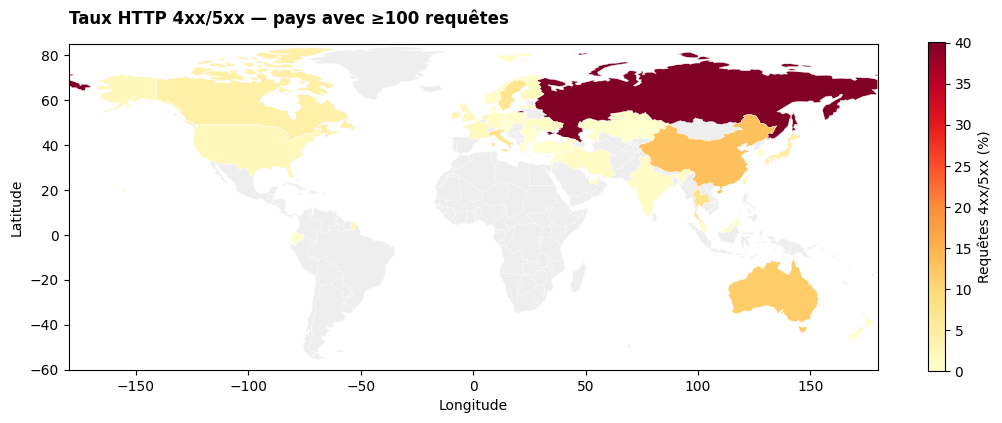

In [6]:
ID_GRAPHIQUE = '07_01'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig,ax=creer_axes()
fond_carte(ax)
for iso,pts in polys:
    if iso in couleurs.index:ax.add_patch(Polygon(pts,facecolor=cmap(norm(couleurs[iso])),edgecolor='white',linewidth=.3))
fig.colorbar(plt.cm.ScalarMappable(norm=norm,cmap=cmap),ax=ax,label='Requêtes 4xx/5xx (%)',shrink=.7)
terminer(ax,'Taux HTTP 4xx/5xx — pays avec ≥100 requêtes','Longitude','Latitude')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn — composition avec Matplotlib</div></b>

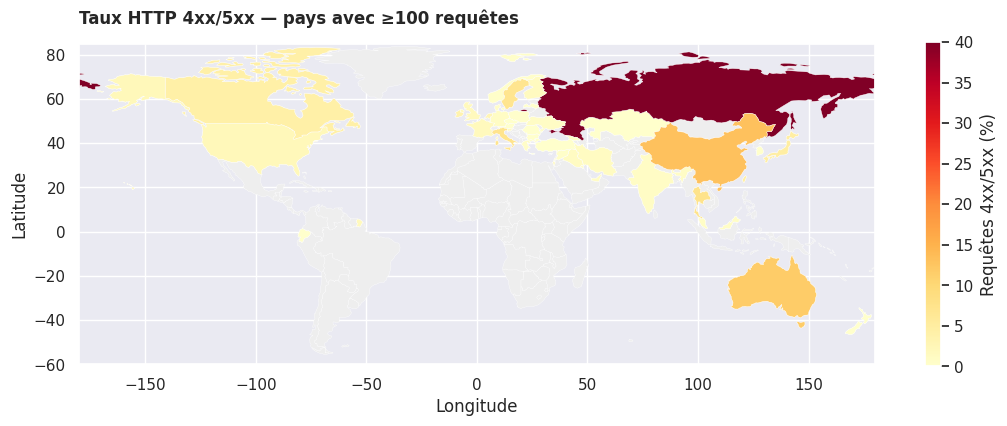

In [7]:
ID_GRAPHIQUE = '07_01'
BIBLIOTHEQUE = 'seaborn'
fig,ax=creer_axes(True)
fond_carte(ax);cm=sns.color_palette('YlOrRd',as_cmap=True)
for iso,pts in polys:
    if iso in couleurs.index:ax.add_patch(Polygon(pts,facecolor=cm(norm(couleurs[iso])),edgecolor='white',linewidth=.3))
fig.colorbar(plt.cm.ScalarMappable(norm=norm,cmap=cm),ax=ax,label='Requêtes 4xx/5xx (%)',shrink=.7)
terminer(ax,'Taux HTTP 4xx/5xx — pays avec ≥100 requêtes','Longitude','Latitude')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

In [8]:
ID_GRAPHIQUE = '07_01'
BIBLIOTHEQUE = 'plotly'
fig=go.Figure();fond_plotly(fig)
for iso,pts in polys:
    if iso in couleurs.index:
        valeur=float(couleurs[iso]);rgb=cmap(norm(valeur))[:3];couleur='rgb('+','.join(str(round(255*t)) for t in rgb)+')'
        fig.add_trace(go.Scatter(x=pts[:,0],y=pts[:,1],fill='toself',fillcolor=couleur,mode='lines',line={'width':.3,'color':'white'},showlegend=False,hovertemplate=f'{iso} : {valeur:.2f}%<extra></extra>'))
fig.add_trace(go.Scatter(x=[None,None],y=[None,None],mode='markers',showlegend=False,marker={'color':[0,float(a.taux.max())],'colorscale':'YlOrRd','showscale':True,'colorbar_title':'4xx/5xx (%)'}))
montrer_plotly(fig,'Taux HTTP 4xx/5xx — pays avec ≥100 requêtes')

**À lire dans les trois variantes :** Comparer le taux de réponses HTTP 4xx/5xx par pays avec au moins 100 requêtes. Structure : géographie G + taux Q. Géolocalisation fournie, approximative ; gris = absent du fond ou effectif insuffisant. Fond Natural Earth joint, projection longitude/latitude simplifiée et contours extérieurs.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>2 — Carte à symboles proportionnels</div></b>

Localiser les 40 positions fournies les plus fréquentes. Structure : longitude + latitude + effectif ; aire proportionnelle aux requêtes. Ces positions peuvent être des centres de géolocalisation, pas des personnes. Les autres positions sont exclues et comptées.

In [9]:
fichier_geo=Path('assets/pays_natural_earth.geojson')
assert fichier_geo.exists(), 'Conserver le dossier assets à côté du notebook.'
geojson=json.loads(fichier_geo.read_text(encoding='utf-8'))
polys=[]
for f in geojson['features']:
    iso=f['properties'].get('ISO_A2_EH',f['properties'].get('ISO_A2'))
    if iso=='AQ':continue
    geom=f['geometry'];blocs=geom['coordinates'] if geom['type']=='MultiPolygon' else [geom['coordinates']]
    for bloc in blocs:polys.append((iso,np.asarray(bloc[0])))
def fond_carte(ax):
    for iso,pts in polys:ax.add_patch(Polygon(pts,facecolor='#eeeeee',edgecolor='white',linewidth=.25))
    ax.set(xlim=(-180,180),ylim=(-60,85),aspect='equal')
def fond_plotly(fig):
    for iso,pts in polys:fig.add_trace(go.Scatter(x=pts[:,0],y=pts[:,1],mode='lines',line={'width':.25,'color':'white'},fill='toself',fillcolor='#eeeeee',hoverinfo='skip',showlegend=False))
    fig.update_xaxes(range=[-180,180],title='Longitude');fig.update_yaxes(range=[-60,85],title='Latitude',scaleanchor='x',scaleratio=1)
pays=donnees.groupby('geo_country_code').agg(n=('status','size'),taux=('erreur','mean')).reset_index()
pays['taux']*=100
codes={iso for iso,_ in polys}
print('Requêtes avec pays cartographiable :',int(pays.loc[pays.geo_country_code.isin(codes),'n'].sum()),'/',len(donnees))
print('Pays absents du fond :',pays.loc[~pays.geo_country_code.isin(codes),'geo_country_code'].tolist())

d=donnees.loc[donnees.geo_latitude.between(-90,90)&donnees.geo_longitude.between(-180,180)]
a=d.groupby(['geo_longitude','geo_latitude']).size().nlargest(40).rename('n').reset_index()
print('Requêtes représentées par les 40 symboles :',a.n.sum(),'; géolocalisées :',len(d))
display(a.head())

Requêtes avec pays cartographiable : 495126 / 499997
Pays absents du fond : ['HK', 'Inconnu', 'SG']
Requêtes représentées par les 40 symboles : 475234 ; géolocalisées : 496377


,geo_longitude,geo_latitude,n
0,51.4115,35.6980,283938
1,-97.8220,37.7510,43563
2,51.4158,35.6824,36522
3,11.0783,49.4527,19028
4,-78.3877,36.6694,9969


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

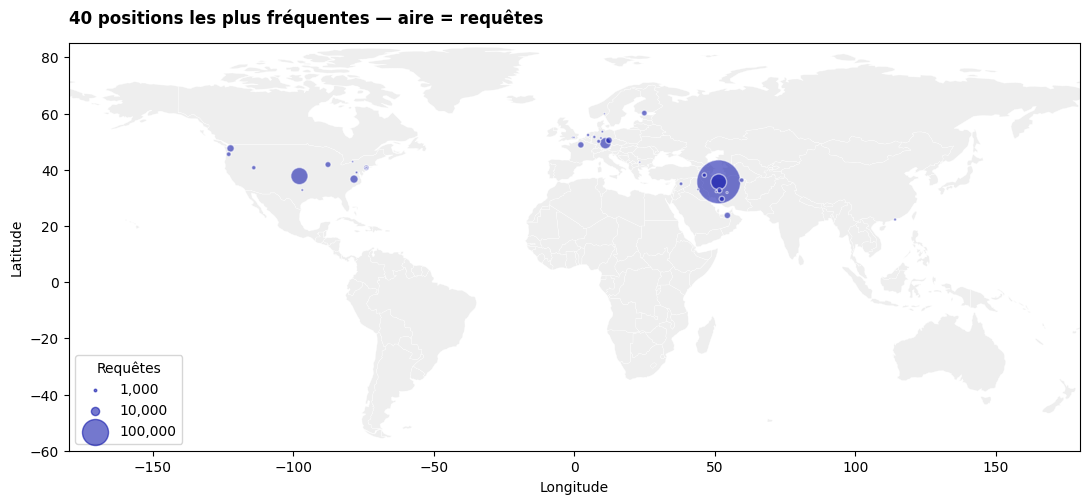

In [10]:
ID_GRAPHIQUE = '07_02'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig,ax=creer_axes()
fond_carte(ax);ax.scatter(a.geo_longitude,a.geo_latitude,s=1000*a.n/a.n.max(),color=palette[0],alpha=.55,edgecolor='white')
for v in [1000,10000,100000]:ax.scatter([],[],s=1000*v/a.n.max(),label=f'{v:,}',color=palette[0],alpha=.55)
ax.legend(title='Requêtes',loc='lower left')
terminer(ax,'40 positions les plus fréquentes — aire = requêtes','Longitude','Latitude')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn — composition avec Matplotlib</div></b>

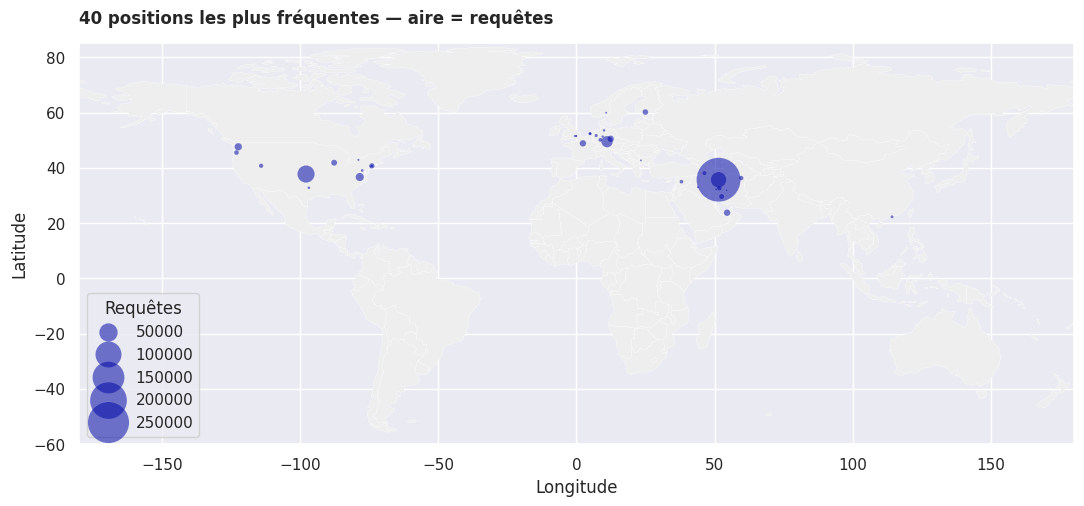

In [11]:
ID_GRAPHIQUE = '07_02'
BIBLIOTHEQUE = 'seaborn'
fig,ax=creer_axes(True)
fond_carte(ax);sns.scatterplot(data=a,x='geo_longitude',y='geo_latitude',size='n',sizes=(1000*a.n.min()/a.n.max(),1000),color=palette[0],alpha=.55,ax=ax);ax.legend(title='Requêtes',loc='lower left')
terminer(ax,'40 positions les plus fréquentes — aire = requêtes','Longitude','Latitude')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

In [12]:
ID_GRAPHIQUE = '07_02'
BIBLIOTHEQUE = 'plotly'
fig=go.Figure();fond_plotly(fig)
fig.add_trace(go.Scatter(x=a.geo_longitude,y=a.geo_latitude,mode='markers',customdata=a.n,hovertemplate='%{customdata:,} requêtes<extra></extra>',marker=dict(size=a.n,sizemode='area',sizeref=2*a.n.max()/45**2,color=palette[0],opacity=.55),showlegend=False))
montrer_plotly(fig,'40 positions les plus fréquentes — aire = requêtes')

**À lire dans les trois variantes :** Localiser les 40 positions fournies les plus fréquentes. Structure : longitude + latitude + effectif ; aire proportionnelle aux requêtes. Ces positions peuvent être des centres de géolocalisation, pas des personnes. Les autres positions sont exclues et comptées.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>3 — Matrice thermique</div></b>

Croiser les dix pays les plus présents et les classes HTTP. Variables : 2C + taux Q. Chaque ligne somme à 100 % : la carte compare des profils, et non des volumes.

In [13]:
top=donnees.geo_country_code.value_counts().head(10).index
counts=pd.crosstab(donnees.geo_country_code,donnees.classe_http).reindex(top,fill_value=0)
a=counts.div(counts.sum(axis=1),axis=0)*100
assert np.allclose(a.sum(axis=1),100)
display(counts.sum(axis=1).rename('n_requetes'));display(a.round(2))

geo_country_code
IR         337870
US          87412
DE          31683
FR           7137
AE           6290
FI           4838
NL           3827
Inconnu      3620
GB           2503
SY           1976
Name: n_requetes, dtype: int64

classe_http,2xx,3xx,4xx,5xx
geo_country_code,,,,
IR,96.55,2.24,1.18,0.02
US,83.73,14.18,2.07,0.03
DE,95.34,3.62,1.01,0.02
FR,86.27,11.90,1.84,0.00
AE,97.92,1.24,0.83,0.02
FI,97.40,1.16,1.45,0.00
NL,94.64,2.64,2.53,0.18
Inconnu,98.04,1.55,0.41,0.00
GB,96.60,1.60,1.80,0.00


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

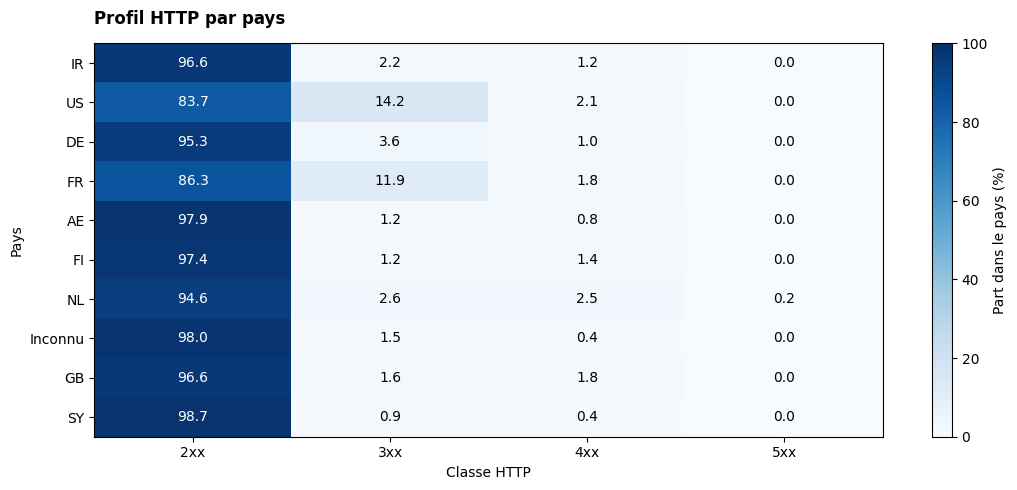

In [14]:
ID_GRAPHIQUE = '07_03'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig,ax=creer_axes()
im=ax.imshow(a,aspect='auto',vmin=0,vmax=100,cmap='Blues');ax.set_xticks(range(len(a.columns)),a.columns);ax.set_yticks(range(len(a)),a.index);fig.colorbar(im,ax=ax,label='Part dans le pays (%)')
for i in range(len(a)):
    for j in range(len(a.columns)):ax.text(j,i,f'{a.iloc[i,j]:.1f}',ha='center',va='center',color='white' if a.iloc[i,j]>50 else 'black')
terminer(ax,'Profil HTTP par pays','Classe HTTP','Pays')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn</div></b>

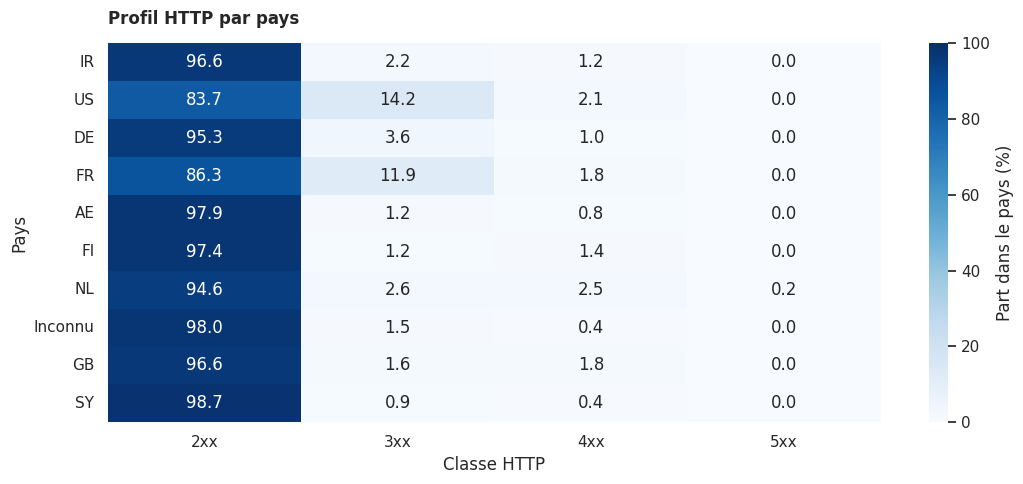

In [15]:
ID_GRAPHIQUE = '07_03'
BIBLIOTHEQUE = 'seaborn'
fig,ax=creer_axes(True)
sns.heatmap(a,vmin=0,vmax=100,cmap='Blues',annot=True,fmt='.1f',cbar_kws={'label':'Part dans le pays (%)'},ax=ax)
terminer(ax,'Profil HTTP par pays','Classe HTTP','Pays')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

In [16]:
ID_GRAPHIQUE = '07_03'
BIBLIOTHEQUE = 'plotly'
fig=px.imshow(a,aspect='auto',zmin=0,zmax=100,color_continuous_scale='Blues',text_auto='.1f',labels={'color':'Part dans le pays (%)'})
montrer_plotly(fig,'Profil HTTP par pays')

**À lire dans les trois variantes :** Croiser les dix pays les plus présents et les classes HTTP. Variables : 2C + taux Q. Chaque ligne somme à 100 % : la carte compare des profils, et non des volumes.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>4 — Sankey</div></b>

Relier le type de référent au type d’appareil pour les mêmes requêtes. Variables : source C + cible C + effectif Q. Ce croisement n’est pas une reconstitution de parcours utilisateurs.

In [17]:
flux=pd.crosstab(donnees.referer_type,donnees.device_type)
assert flux.to_numpy().sum()==len(donnees)
liens=flux.rename_axis('referent').reset_index().melt(id_vars='referent',var_name='appareil',value_name='n')
liens=liens.loc[liens.n.gt(0)].copy()
# Pavage vertical cohérent des flux aux deux extrémités ; hauteur = part du total.
total=float(flux.to_numpy().sum());g=.065
def positions(totaux):
    y=0;res={}
    for nom,n in totaux.items():res[nom]=(y,y+n/total);y+=n/total+g
    return res
gauche=positions(flux.sum(axis=1));droite=positions(flux.sum(axis=0))
offset_g={k:v[0] for k,v in gauche.items()};offset_d={k:v[0] for k,v in droite.items()}
rubans=[]
for r in liens.itertuples():
    h=r.n/total;yg=offset_g[r.referent];yd=offset_d[r.appareil]
    t=np.linspace(0,1,60);lissage=3*t*t-2*t*t*t;bas=yg+(yd-yg)*lissage
    pts=np.c_[np.r_[t,t[::-1]],np.r_[bas,(bas+h)[::-1]]]
    rubans.append((pts,r.referent,r.appareil,r.n));offset_g[r.referent]+=h;offset_d[r.appareil]+=h
display(flux)

device_type,Bot,Mobile,Other,PC,Tablet
referer_type,,,,,
Direct,60622,6052,2899,10296,12376
External,48,5689,0,29027,127
Internal,2647,80475,897,279688,5400
Search Engine,2,1257,1,2271,216
Social,0,5,0,2,0


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

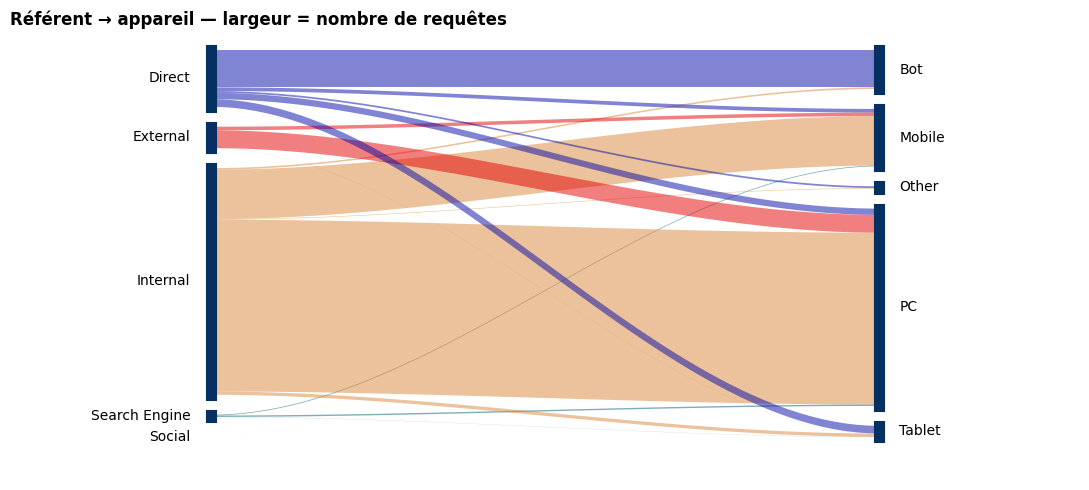

In [18]:
ID_GRAPHIQUE = '07_04'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig,ax=creer_axes(False)
for pts,source,cible,n in rubans:ax.add_patch(Polygon(pts,facecolor=palette[list(gauche).index(source)],alpha=.5,edgecolor='none'))
for cote,x in [(gauche,0),(droite,1)]:
    for nom,(y0,y1) in cote.items():
        ax.plot([x,x],[y0,y1],color='#053061',linewidth=8);ax.text(x+(-.03 if x==0 else .03),(y0+y1)/2,nom,ha='right' if x==0 else 'left',va='center',fontsize=10)
ax.set(xlim=(-.3,1.3),ylim=(-.02,1.4));ax.invert_yaxis();ax.axis('off')
terminer(ax,'Référent → appareil — largeur = nombre de requêtes')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn — composition avec Matplotlib</div></b>

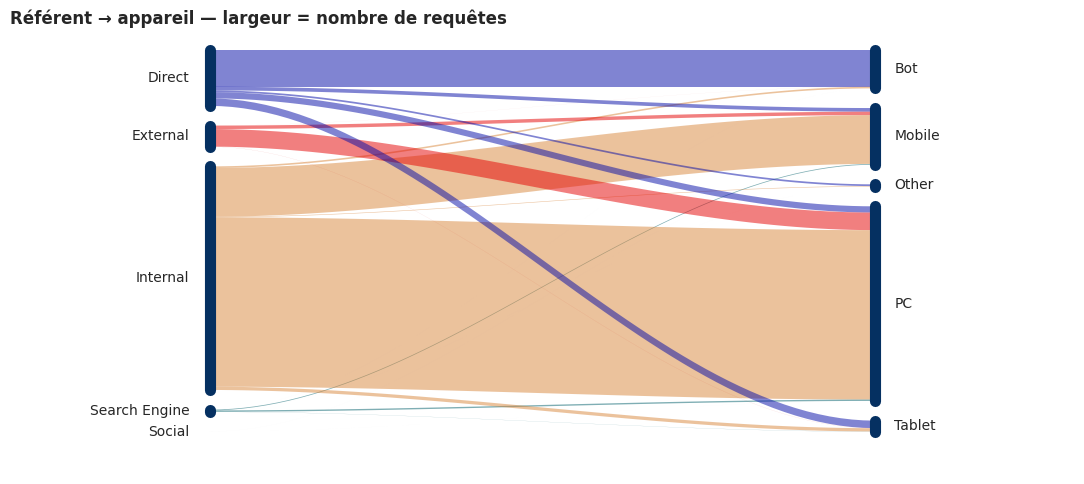

In [19]:
ID_GRAPHIQUE = '07_04'
BIBLIOTHEQUE = 'seaborn'
fig,ax=creer_axes(True)
for pts,source,cible,n in rubans:ax.add_patch(Polygon(pts,facecolor=palette[list(gauche).index(source)],alpha=.5,edgecolor='none'))
for cote,x in [(gauche,0),(droite,1)]:
    for nom,(y0,y1) in cote.items():
        ax.plot([x,x],[y0,y1],color='#053061',linewidth=8);ax.text(x+(-.03 if x==0 else .03),(y0+y1)/2,nom,ha='right' if x==0 else 'left',va='center',fontsize=10)
ax.set(xlim=(-.3,1.3),ylim=(-.02,1.4));ax.invert_yaxis();ax.axis('off')
terminer(ax,'Référent → appareil — largeur = nombre de requêtes')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

In [20]:
ID_GRAPHIQUE = '07_04'
BIBLIOTHEQUE = 'plotly'
labels=['Référent : '+s for s in flux.index]+['Appareil : '+s for s in flux.columns];index={s:i for i,s in enumerate(labels)}
fig=go.Figure(go.Sankey(node=dict(label=labels,pad=18,thickness=18),link=dict(source=[index['Référent : '+s] for s in liens.referent],target=[index['Appareil : '+s] for s in liens.appareil],value=liens.n)))
montrer_plotly(fig,'Référent → appareil — largeur = nombre de requêtes')

**À lire dans les trois variantes :** Relier le type de référent au type d’appareil pour les mêmes requêtes. Variables : source C + cible C + effectif Q. Ce croisement n’est pas une reconstitution de parcours utilisateurs.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>5 — Réseau biparti</div></b>

Représenter les associations référent–appareil comme un réseau pondéré. Variables : deux catégories C + poids Q. La position est un agencement graphique ; elle ne représente ni une distance géographique ni une causalité.

In [21]:
flux=pd.crosstab(donnees.referer_type,donnees.device_type)
assert flux.to_numpy().sum()==len(donnees)
liens=flux.rename_axis('referent').reset_index().melt(id_vars='referent',var_name='appareil',value_name='n')
liens=liens.loc[liens.n.gt(0)].copy()
# Pavage vertical cohérent des flux aux deux extrémités ; hauteur = part du total.
total=float(flux.to_numpy().sum());g=.065
def positions(totaux):
    y=0;res={}
    for nom,n in totaux.items():res[nom]=(y,y+n/total);y+=n/total+g
    return res
gauche=positions(flux.sum(axis=1));droite=positions(flux.sum(axis=0))
offset_g={k:v[0] for k,v in gauche.items()};offset_d={k:v[0] for k,v in droite.items()}
rubans=[]
for r in liens.itertuples():
    h=r.n/total;yg=offset_g[r.referent];yd=offset_d[r.appareil]
    t=np.linspace(0,1,60);lissage=3*t*t-2*t*t*t;bas=yg+(yd-yg)*lissage
    pts=np.c_[np.r_[t,t[::-1]],np.r_[bas,(bas+h)[::-1]]]
    rubans.append((pts,r.referent,r.appareil,r.n));offset_g[r.referent]+=h;offset_d[r.appareil]+=h
display(flux)

graphe=nx.Graph()
for r in liens.itertuples():graphe.add_edge('R:'+r.referent,'A:'+r.appareil,weight=r.n)
pos={**{'R:'+s:(0,-j) for j,s in enumerate(flux.index)},**{'A:'+s:(1,-j) for j,s in enumerate(flux.columns)}}
maximum=liens.n.max()

device_type,Bot,Mobile,Other,PC,Tablet
referer_type,,,,,
Direct,60622,6052,2899,10296,12376
External,48,5689,0,29027,127
Internal,2647,80475,897,279688,5400
Search Engine,2,1257,1,2271,216
Social,0,5,0,2,0


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

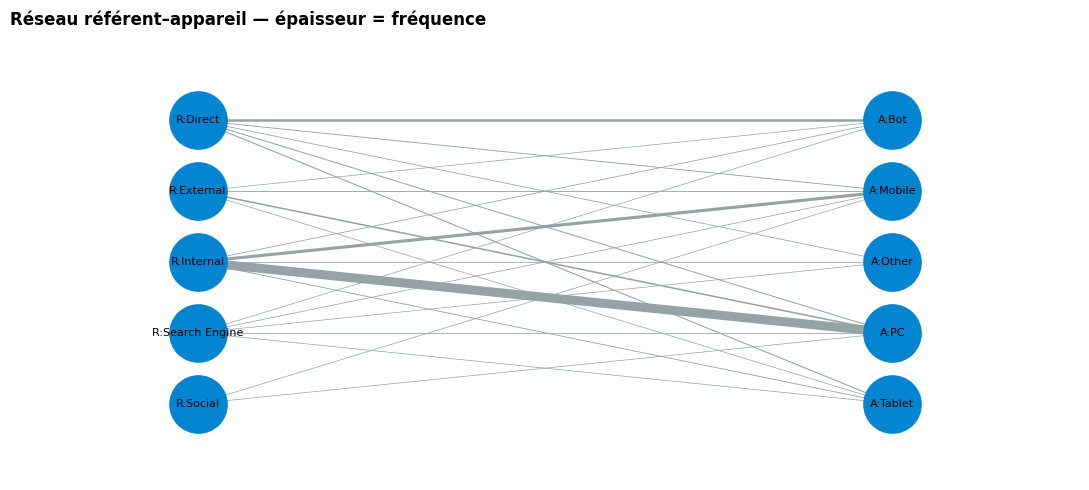

In [22]:
ID_GRAPHIQUE = '07_05'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig,ax=creer_axes()
largeurs=[.5+6*graphe[u][v]['weight']/maximum for u,v in graphe.edges]
nx.draw_networkx(graphe,pos=pos,ax=ax,node_color=palette[6],node_size=1700,width=largeurs,font_size=8,edge_color='#95a3a6');ax.axis('off');ax.margins(.2)
terminer(ax,'Réseau référent–appareil — épaisseur = fréquence')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn — composition avec Matplotlib</div></b>

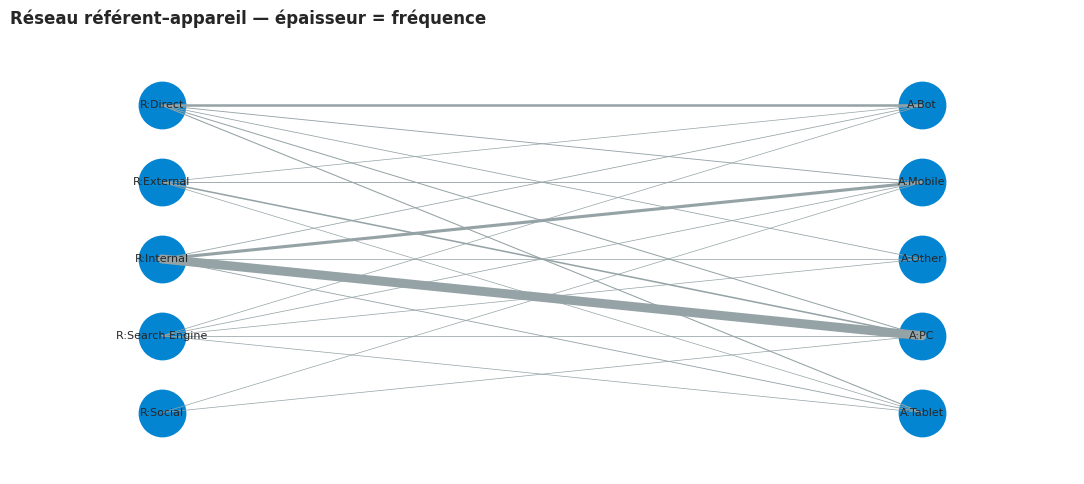

In [23]:
ID_GRAPHIQUE = '07_05'
BIBLIOTHEQUE = 'seaborn'
fig,ax=creer_axes(True)
for u,v in graphe.edges:
    ax.plot([pos[u][0],pos[v][0]],[pos[u][1],pos[v][1]],linewidth=.5+6*graphe[u][v]['weight']/maximum,color='#95a3a6')
nodes=pd.DataFrame([{'nom':s,'x':xy[0],'y':xy[1]} for s,xy in pos.items()]);sns.scatterplot(data=nodes,x='x',y='y',s=1400,color=palette[6],ax=ax)
for r in nodes.itertuples():ax.text(r.x,r.y,r.nom,ha='center',va='center',fontsize=8)
ax.axis('off');ax.margins(.2)
terminer(ax,'Réseau référent–appareil — épaisseur = fréquence')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

In [24]:
ID_GRAPHIQUE = '07_05'
BIBLIOTHEQUE = 'plotly'
fig=go.Figure()
for u,v in graphe.edges:fig.add_trace(go.Scatter(x=[pos[u][0],pos[v][0]],y=[pos[u][1],pos[v][1]],mode='lines',line=dict(width=.5+6*graphe[u][v]['weight']/maximum,color='#95a3a6'),showlegend=False,hovertemplate=f'{u} → {v} : {graphe[u][v]["weight"]:,}<extra></extra>'))
fig.add_trace(go.Scatter(x=[p[0] for p in pos.values()],y=[p[1] for p in pos.values()],text=list(pos),mode='markers+text',textposition='top center',marker=dict(size=22,color=palette[6]),showlegend=False))
fig.update_xaxes(visible=False,range=[-.25,1.25]);fig.update_yaxes(visible=False)
montrer_plotly(fig,'Réseau référent–appareil — épaisseur = fréquence')

**À lire dans les trois variantes :** Représenter les associations référent–appareil comme un réseau pondéré. Variables : deux catégories C + poids Q. La position est un agencement graphique ; elle ne représente ni une distance géographique ni une causalité.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>6 — Gantt de fenêtres d’observation</div></b>

Visualiser les intervalles entre première et dernière requête par appareil dans chaque heure. Variables : catégorie C + début T + fin T. Ces barres ne sont pas des durées de session ni une preuve d’activité continue.

In [25]:
d=donnees.copy();d['heure']=d.datetime.dt.floor('h')
a=d.groupby(['device_type','heure']).datetime.agg(debut='min',fin='max').reset_index()
a['duree_minutes']=(a.fin-a.debut).dt.total_seconds()/60
a['label']=a.device_type+' · '+a.heure.dt.strftime('%Hh')
display(a[['label','debut','fin','duree_minutes']].head())

,label,debut,fin,duree_minutes
0,Bot · 00h,2019-01-22 00:26:14+00:00,2019-01-22 00:59:59+00:00,33.750000
1,Bot · 01h,2019-01-22 01:00:00+00:00,2019-01-22 01:59:59+00:00,59.983333
2,Bot · 02h,2019-01-22 02:00:00+00:00,2019-01-22 02:59:59+00:00,59.983333
3,Bot · 03h,2019-01-22 03:00:00+00:00,2019-01-22 03:59:59+00:00,59.983333
4,Bot · 04h,2019-01-22 04:00:00+00:00,2019-01-22 04:59:59+00:00,59.983333


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

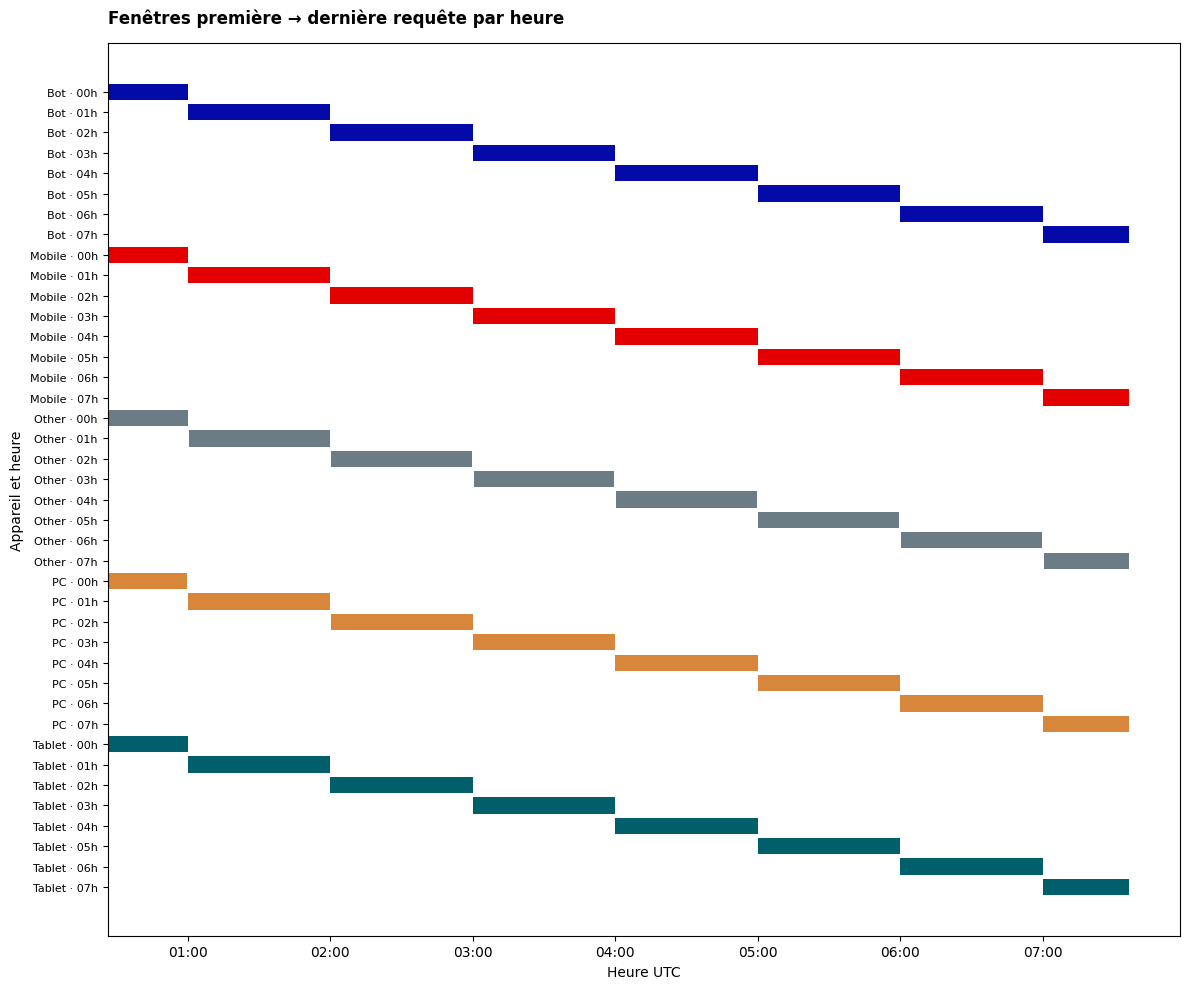

In [26]:
ID_GRAPHIQUE = '07_06'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig,ax=plt.subplots(figsize=(12,10))
for j,r in enumerate(a.itertuples()):ax.barh(j,mdates.date2num(r.fin)-mdates.date2num(r.debut),left=mdates.date2num(r.debut),color=palette[list(donnees.device_type.unique()).index(r.device_type)])
ax.set_yticks(range(len(a)),a.label,fontsize=8);ax.invert_yaxis();ax.xaxis_date();ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
terminer(ax,'Fenêtres première → dernière requête par heure','Heure UTC','Appareil et heure')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn — composition avec Matplotlib</div></b>

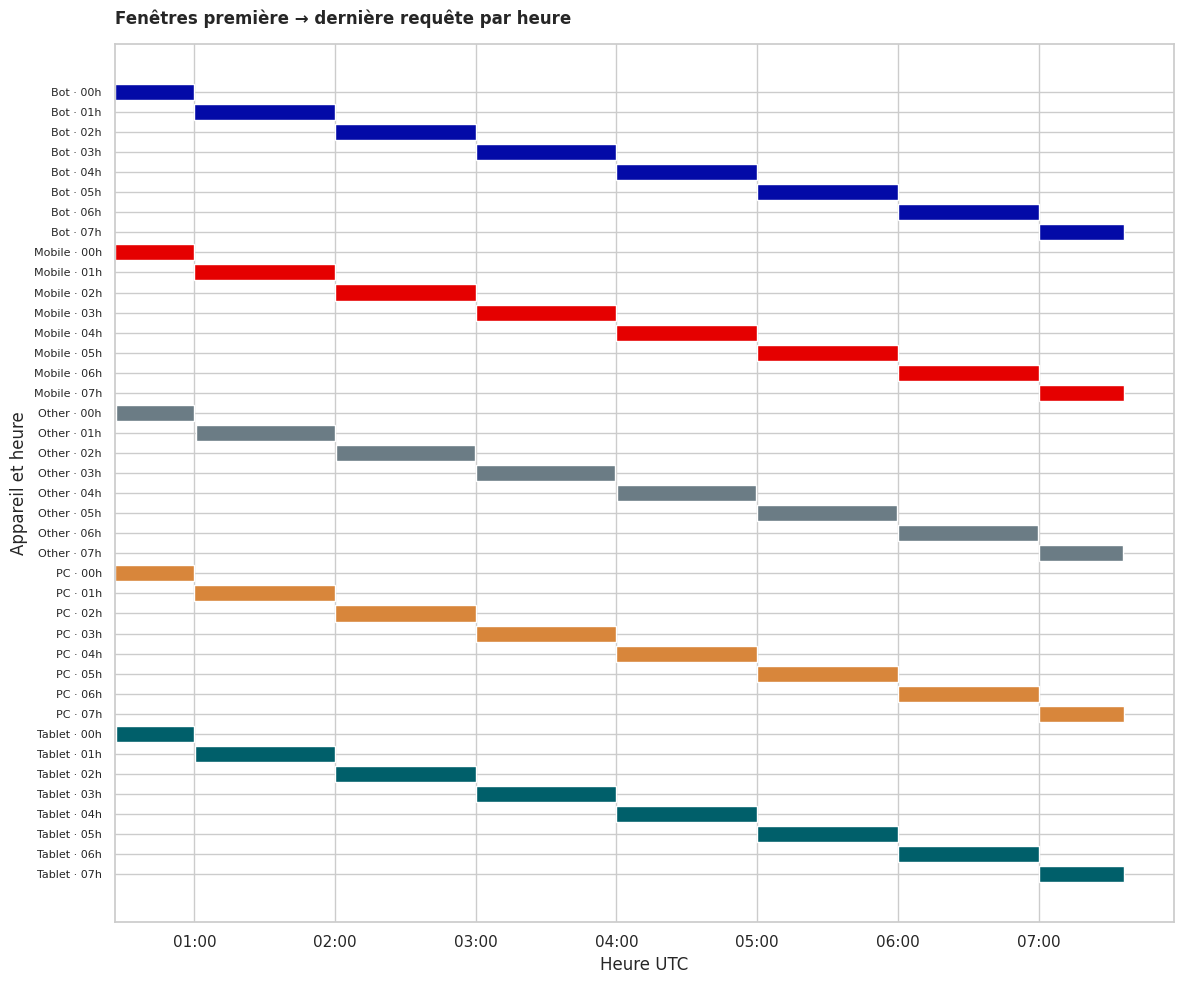

In [27]:
ID_GRAPHIQUE = '07_06'
BIBLIOTHEQUE = 'seaborn'
sns.set_theme(style='whitegrid',palette=palette)
fig,ax=plt.subplots(figsize=(12,10))
for j,r in enumerate(a.itertuples()):ax.barh(j,mdates.date2num(r.fin)-mdates.date2num(r.debut),left=mdates.date2num(r.debut),color=sns.color_palette(palette)[list(donnees.device_type.unique()).index(r.device_type)])
ax.set_yticks(range(len(a)),a.label,fontsize=8);ax.invert_yaxis();ax.xaxis_date();ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
terminer(ax,'Fenêtres première → dernière requête par heure','Heure UTC','Appareil et heure')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

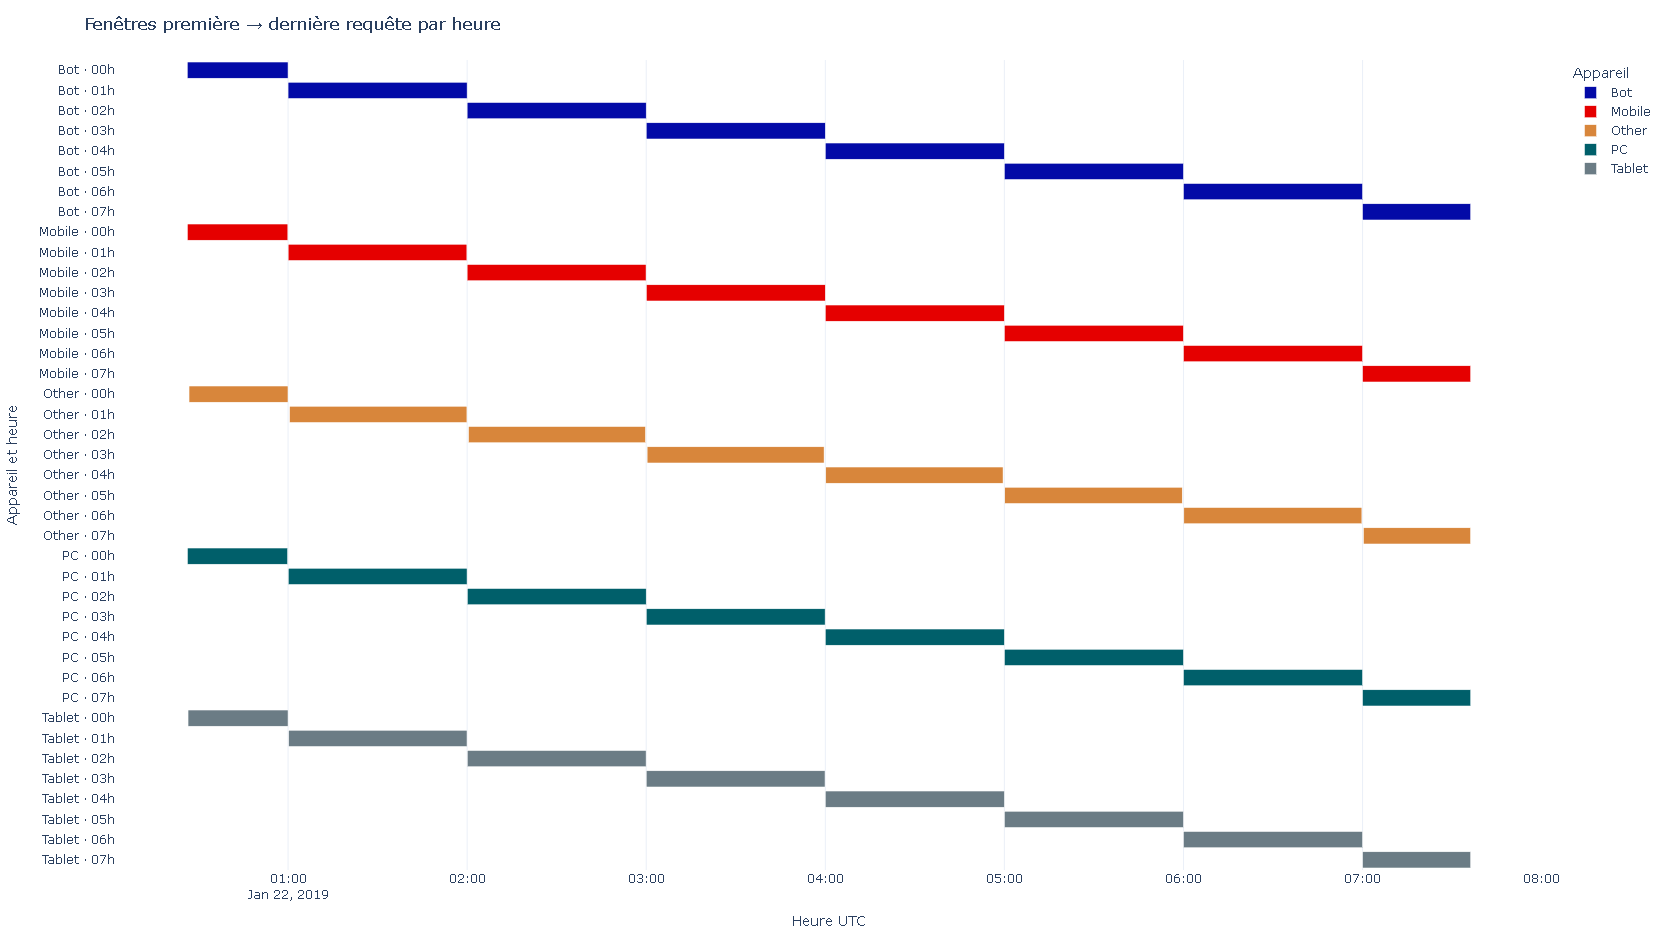

In [28]:
ID_GRAPHIQUE = '07_06'
BIBLIOTHEQUE = 'plotly'
fig=px.timeline(a,x_start='debut',x_end='fin',y='label',color='device_type',hover_data=['duree_minutes'],labels={'label':'Appareil et heure','device_type':'Appareil'})
fig.update_yaxes(autorange='reversed');fig.update_layout(height=950,title='Fenêtres première → dernière requête par heure');fig.update_xaxes(title='Heure UTC');fig.show()

**À lire dans les trois variantes :** Visualiser les intervalles entre première et dernière requête par appareil dans chaque heure. Variables : catégorie C + début T + fin T. Ces barres ne sont pas des durées de session ni une preuve d’activité continue.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Synthèse et exercices</div></b>

1. Reformuler la question métier de chacun des six graphiques.
2. Modifier un filtre ou une période et expliquer son effet sur le dénominateur.
3. Choisir une variante pour un rapport imprimé et une pour un tableau de bord interactif.
4. Vérifier l’unité, l’effectif, les valeurs manquantes et le sens des encodages.

**Limites :** Le fichier couvre seulement le 22 janvier 2019, de 00:26 à 07:36 UTC environ. Les premières et dernières minutes sont incomplètes. Les mesures portent sur des requêtes, pas sur des personnes. Les adresses IP et URL brutes ne sont pas chargées.

Fond géographique complémentaire : [Natural Earth, dépôt officiel](https://github.com/nvkelso/natural-earth-vector), `ne_110m_admin_0_countries.geojson`, téléchargé le 29 septembre 2026 ; [domaine public](https://www.naturalearthdata.com/about/terms-of-use/). Le fond ne fournit aucune mesure métier. Contours extérieurs simplifiés, sans représentation des trous internes, et projection plate longitude/latitude. Les petits territoires absents sont signalés. Le fichier est joint pour une exécution hors ligne.